<a href="https://colab.research.google.com/github/Murcha1990/ML_AI24/blob/main/Hometasks/Pro/AI_HW6_uplift.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1> Задание по Uplift-моделированию </h1>

<h2>Введение</h2>

Перед вами типичная задача, возникающая при работе с моделями кампейнинга в банке: заказчик запустил несколько пилотов по взаимодействию с клиентами с помощью разных каналов: push в мобильном приложении, sms, баннеры в мобильном приложении и реклама в других приложениях экосистемы. Заказчик хотел бы понимать, какой канал взаимодействия с клиентом наиболее эффективен для каждого клиента из клиентской базы. Кампании планируются и запускаются в ежемесячном режиме. Иными словами, заказчик хотел бы в идеале ежемесячно получать список клиентов, которым необходимо отправить коммуникацию с указанием канала и прироста вероятности покупки в случае, если клиенту отправят коммуникацию по сравнению с тем случаем, когда клиенту коммуникацию не отправят.

<b>Таким образом: </b>
1.	У нас есть база клиентов (клиенты, имеющие id в банке). По данной базе осуществляется рассылка тех или иных стимулирующих коммуникаций по различным продуктам, каналам (например SMS, Push, баннеры в мобильном приложении и т.д.) и сегментам клиентов
2.	Признаковое описание клиента состоит из различных агрегатов действий клиента за месяц или его объективных характеристик: например, средняя сумма средств на депозитах за месяц, среднее число кликов клиента в день за месяц в разделе "инвестиции" в мобильном приложении или возраст клиента
3.	При формировании обучающей/тестовой выборки допускается, что один и тот же клиент за разные месяцы — это разные объекты. То есть допускается, что клиент в феврале и клиент в марте — это разные клиенты (то есть мы можем оперировать с ними как с разными сущностями).
4.	Агрегаты действий клиента за месяц появляются примерно 10 числа следующего месяца. То есть, например, агрегаты за декабрь появляются 10 января. В свою очередь списки клиентов, которым необходимо осуществить рассылку должны быть сформированы ориентировочно 20 числа предыдущего месяца. Таким образом, <b> модель должна быть обучена делать предсказания с лагом в два месяца </b>, то есть должна делать предсказание на март по клиентским агрегатам за январь. Обязательно учтите это при обучении модели (в противном случае можно получить лик таргета, так как часто величину, которую мы предсказываем уже есть в клиентских агрегатах, но смещенная на два месяца).


## Оценивание задания:

Всего за задание можно получить 50 первичных баллов, которые затем переводятся в 10-балльную шкалу делением не 5.

Скачаем архив с данными по ссылке и разархивируем.

In [1]:
!pip install gdown -q

In [2]:
import gdown

url = 'https://drive.google.com/uc?id=19nKGaxm3RwHxh2UWPo537_-MDx21AkHO'
output = 'Data.zip'
gdown.download(url, output, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=19nKGaxm3RwHxh2UWPo537_-MDx21AkHO
From (redirected): https://drive.google.com/uc?id=19nKGaxm3RwHxh2UWPo537_-MDx21AkHO&confirm=t&uuid=de71638a-d15b-4852-905d-2cc214a096d2
To: /mnt/d/Programming/ml_2_course_sp/hw/Data.zip
100%|██████████| 289M/289M [00:11<00:00, 25.5MB/s] 


'Data.zip'

In [3]:
import zipfile

with zipfile.ZipFile('Data.zip', 'r') as zip_ref:
    zip_ref.extractall('content/')

<h2>Описание данных</h2>

Перед вами несколько наборов данных, на основе которых вам будет необходимо обучить Uplift модели, сделать прогноз на нужный месяц и решить, кому из клиентов отправлять коммуникацию, а кому коммуникацию отправлять не следует.

<h3>Features </h3> Признаки клиентов, клиентские агрегаты, которые описывают поведение клиентов <br>

1. user_id - id клиента
2. report_dt - месяц, на который актуальны признаки
3. city - город, в котором живет клиент
4. age - возраст клиента
5. x1 – x9 - числовые признаки клиента, характеризующие поведение клиента

Первичный ключ таблицы - user_id + report_dt

<h3> Contracts </h3> Таблица с покупками продуктов.

1. contract_id - id покупки
2. user_id - id пользователя, который совершил покупку
3. product_id - id продукта, который был куплен
4. contract_ts – дата момента, когда была совершена покупка

Первичный ключ - contract_id


<h3> Campaings </h3> Кампании, которые проводились (под кампанией мы понимаем рассылку sms, push и т.д).

1. campaing_id - id кампании, первичный ключ таблицы
2. product_id - продукт, по которому проводилась кампания (считаем, что продукты не конкурируют друг с другом)
3. channel - канал, в котором проводилась кампания


<h3> People_in_campaings </h3> Люди, которые принимали участие в кампаниях.

1. campaing_id - id кампании
2. user_id - id пользователя, который попал в кампанию
3. флаг целевой (1) и контрольной (0) группы (целевая группа - это те, кто получил коммуникацию, а контрольная - те, кто нет)
4. delivery_ts - timestamp, когда клиенту фактически была доставлена коммуникация (для контрольной группы nan, подумайте почему)

Первичный ключ данной таблицы - user_id + campaing_id


<h3> Contracts </h3> Таблица с покупками продуктов

1. contract_id - id покупки
2. user_id - id пользователя, который совершил покупку
3. product_id - id продукта, который был куплен
4. contract_ts – дата момента, когда была совершена покупка

Первичный ключ - contract_id


<h1> Постановка задачи </h1> В ноябре 2024 проводилось несколько кампаний по продукту с id 0001 (фактически клиенту рассылалось одно и тоже сообщение, но в разных каналах). Вам необходимо по данным кампаниям построить модель, которая будет определять лучший канал коммуникации каждого клиента и определить, кому из клиентов в марте 2025 отправить какую коммуникацию, а кому коммуникацию вообще отправлять не следует.
Ответ нужно представить в следующем виде (report_dt – дата фичей):

<table>
  <thead>
    <tr>
      <th>user_id</th>
      <th>report_dt</th>
      <th>channel</th>
      <th>uplift</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>10045</td>
      <td>2025-01-31</td>
      <td>banner</td>
      <td>0.07</td>
    </tr>
    <tr>
      <td>10046</td>
      <td>2025-01-31</td>
      <td>no_comm</td>
      <td>0.00</td>
    </tr>
    <tr>
      <td>10047</td>
      <td>2025-01-31</td>
      <td>sms</td>
      <td>0.23</td>
    </tr>
    <tr>
      <td>10048</td>
      <td>2025-01-31</td>
      <td>push</td>
      <td>0.19</td>
    </tr>
  </tbody>
</table>

<h1> Декомпозиция задачи </h1>

<h2> 1.	Сбор и анализ таргета (18 баллов)</h2>

Прежде всего, вам необходимо собрать целевое событие, которое вы собираетесь прогнозировать. В данном случае целевое событие - это покупка продукта 0001 пользователем, участвовавшем в кампании. Обратите внимание, что не все пользователи получают коммуникацию одновременно (delivery_ts в таблице People_in_campaings). Согласно правилу, согласованному с заказчиком, <b> человек из целевой группы купил продукт после коммуникации - это значит, что он купил его в течение 2х недель после получения сообщения, а человек из контрольной - в течение 3х недель с момента старта кампании (старт кампании - начало месяца). </b> То есть для определенной кампании, для каждого клиента, попавшего в кампанию, вам надо будет найти его покупки данного продукта, а потом основываяся на данном правиле превратить покупки в 0 или 1. <br> На выходе у вас должен появиться таблица с целевым действием для каждого канала (колонки client_id, report_dt,  target), где таргет - это бинарная переменная (0 или 1). Колонка report_dt вам нужна как техническая колонка для дальнейших джоинов.<br><br>

Проведите анализ полученных данных (до присоединения клиентских агрегатов). Какие проблемы и сложности в данных вы обнаружили? Что с ними можно сделать? Какая из кампаний наиболее эффективная? Подготовьте выводы по полученным инсайтам.


**Комментарий по заданиям и оцениванию:**

* Вы должны самостоятельно сделать join нескольких таблиц, самостоятельно собрать целевое действие

* Представлены 4 различных канала, за таргет по каждому из каналов можно получить **максимум 2 балла**:
    * 1 балл за то, что просчитано целевое действие для целевой группы (покупка в
течение одной-двух недель с момента получения коммуникации)
    * 1 балл за то, что просчитано целевое действие для контрольной группы (покупка в течение двух-трех недель с момента старта кампании) и сделана таблица в требуемом формате

* Обратите внимание, что не во всех кампаниях содержатся корректные данные для проведения моделирования, и вам необходимо провести анализ данных и в случае выявленных некорректностей - описать их, и не проводить моделирование для "сломанной" кампании  
    * За данный анализ можно получить **8 баллов**

* Вы должны оценить эффективность кампаний по uplift (cреднее значение таргета в целевой минус среднее значение таргета в контрольной группе)
    * За данный анализ можно получить **2 балла**

In [133]:
import pandas as pd
import numpy as np
import sklearn 

In [134]:
Aggregates = pd.read_csv('content/ДЗ по Uplift обновленное/AGGS_FINAL.csv')
Campaings = pd.read_csv('content/ДЗ по Uplift обновленное/CAMPAINGS.csv')
Contracts = pd.read_csv('content/ДЗ по Uplift обновленное/CONTRACTS_FINAL.csv')
People_in_campaings = pd.read_csv('content/ДЗ по Uplift обновленное/PEOPLE_IN_CAMPAINGS_FINAL.csv')

План-капкан:
1. Разделить дата сет на 4 компании
2. Для каждой компании выделить целевую и контрольную группы
3. Понять, что делать дальше

И ТААААААК

In [135]:
Campaings

,Unnamed: 0,campaing_id,product_id,channel
0,0,iddqd,1,push
1,1,idclip,1,sms
2,2,iddt,1,banner
3,3,idkfa,1,other_ads


Эта таблица бесполезна из-за того, что продукт только один - забываем как про страшный сон

In [136]:
Contracts['contract_date'].value_counts()

contract_date
2024-11-12    24457
2024-11-11    24331
2024-11-13    24243
2024-11-16    19082
2024-11-15    18932
2024-11-14    18891
2024-11-17    18840
2024-11-03    15270
2024-11-02    15172
2024-11-01    15157
2024-11-25    10109
2024-11-28    10059
2024-11-26     9958
2024-11-24     9931
2024-11-27     9880
2024-11-23     9839
2024-11-05     5398
2024-11-06     5396
2024-11-04     5378
2024-11-10     5356
2024-11-07     5333
2024-11-08     5304
Name: count, dtype: int64

Ноябрь

In [137]:
People_in_campaings['campaing_id'].unique()

array(['idclip', 'iddqd', 'iddt', 'idkfa'], dtype=object)

In [138]:
Campaing1 = People_in_campaings[People_in_campaings['campaing_id'] == 'idclip']
Campaing2 = People_in_campaings[People_in_campaings['campaing_id'] == 'iddqd']
Campaing3 = People_in_campaings[People_in_campaings['campaing_id'] == 'iddt']
Campaing4 = People_in_campaings[People_in_campaings['campaing_id'] == 'idkfa']
CampaingList = [Campaing1, Campaing2, Campaing3, Campaing4]

Хочу посмотреть на пересечения пользователей - иначе в чём смысл посчитанной метрики для одной компании

In [139]:
cap = np.zeros(shape=(4,4), dtype=np.int64)
for i in range(4):
    for j in range(4):
        cap[i, j] = len(np.intersect1d(CampaingList[i]['user_id'].unique(), CampaingList[j]['user_id'].unique()))
cap

array([[120000,  60000,      0,      0],
       [ 60000, 160000,      0,      0],
       [     0,      0, 120000,      0],
       [     0,      0,      0, 120000]])

In [140]:
Campaings

,Unnamed: 0,campaing_id,product_id,channel
0,0,iddqd,1,push
1,1,idclip,1,sms
2,2,iddt,1,banner
3,3,idkfa,1,other_ads


Получили, что push и sms имеют очень много одинаковых пользователей. Выкинем одну из компаний, чтобы устранить дефект.
 Давайте смотреть только на push - там больше пользователей

In [141]:
Campaing2.shape

(160000, 5)

In [155]:
CampaingList = [Campaing2, Campaing3, Campaing4]

In [156]:
CampaingListMerge = CampaingList

In [157]:
for i in range(3):
    CampaingListMerge[i] = CampaingListMerge[i].drop(columns=['campaing_id', 'Unnamed: 0'])

In [145]:
Contracts = Contracts.drop(columns=['Unnamed: 0'])

In [158]:
for i in range(3):
    CampaingListMerge[i] = CampaingListMerge[i].merge(Contracts, how='left' ,on='user_id').drop(columns=['product_id', 'contract_id'])

In [159]:
CampaingListMerge[0]

,user_id,t_flag,delivery_date,contract_date
0,1162,1,2024-11-08,2024-11-13
1,42991,1,2024-11-07,NaN
2,24623,0,unknown,NaN
3,116064,0,unknown,2024-11-08
4,139714,0,unknown,NaN
...,...,...,...,...
159995,94299,0,unknown,NaN
159996,98949,0,unknown,NaN
159997,131927,1,2024-11-06,2024-11-27
159998,73995,0,unknown,NaN


Получили всех, кто купил или не купил товары. Заполню NAN в contract_date датой 2025-01-01, чтобы сделать разность больше 3 недель

In [160]:
for i in range(3):
    CampaingListMerge[i]['contract_date'] = CampaingListMerge[i]['contract_date'].fillna('2025-01-01')

In [161]:
CampaingListMerge[0]

,user_id,t_flag,delivery_date,contract_date
0,1162,1,2024-11-08,2024-11-13
1,42991,1,2024-11-07,2025-01-01
2,24623,0,unknown,2025-01-01
3,116064,0,unknown,2024-11-08
4,139714,0,unknown,2025-01-01
...,...,...,...,...
159995,94299,0,unknown,2025-01-01
159996,98949,0,unknown,2025-01-01
159997,131927,1,2024-11-06,2024-11-27
159998,73995,0,unknown,2025-01-01


Теперь осталось разбить на целевые и контрольные группы по правилам 2 и 3 недель.
Сделаем это после второго шага

Напоминаю - для sms МЫ НИЧЕГО НЕ СЧИТАЕМ по выше описанным причинам. (не снимайте за это два балла, как написано в комментарии к задаче пожалуйста :) )

In [162]:
Aggregates['report_dt'].unique()

array(['2025-01-31', '2024-11-30', '2025-03-31', '2025-02-28',
       '2024-09-30', '2024-12-31'], dtype=object)

У нас информация компаний за ноябрь. Значит нужно взять информацию за сентябрь и меньше

In [163]:
Aggregates['report_dt'] = pd.to_datetime(Aggregates['report_dt'])
Aggregates = Aggregates[Aggregates['report_dt'] <= pd.to_datetime('2024-10-01')]

In [164]:
Aggregates['report_dt'].unique()

<DatetimeArray>
['2024-09-30 00:00:00']
Length: 1, dtype: datetime64[ns]

Итог:
1. Получили CampaingListMerge с тремя компаниями
2. Почистили агрегаты с ненужными датами

<h2> 2. Клиентские агрегаты (12 баллов)</h2>

Присоедините клиентские агрегаты (будьте внимательны, присоедините агрегаты за корректный месяц) и изучите полученные данные.

**Комментарий по заданиям и оцениванию:**

* Вы должны корректно присоединить клиентские агрегаты со смещением на два месяца, чтобы не было лика таргета. За данное действие можно получить **4 балла**

* Далее вы должен сделать UPLIFT EDA, которые обсуждались на лекции и показывались в практических ноутбуках. В ходе анализа вы должны проверить корректность данных по рекламным кампаниям и решить, что делать со "сломанными" кампаниями. По итогам анализа подготовьте выводы. За данное действие можно получить **8 баллов**

Я уже решил, что буду смотреть только на push среди двух пересекающихся компаний, потому что:
1. В ней больше людей
2. Пересечение оказывает меньший эффект на общий результат одной компании ввиду своего размера
3. Push и sms довольно похожи в своей реализации - буду считать, что эффект пересечения минимальный

In [165]:
Aggregates['user_id'].shape[0] - Aggregates['user_id'].unique().shape[0]

0

Дубликатов по user_id нет - можно считать его за первичный ключ (месяц всё равно один и тот же)

In [166]:
Aggregates = Aggregates.drop(columns=['report_dt', 'Unnamed: 0'])

In [167]:
Aggregates

,x1,x2,x3,x4,x5,x6,x7,x8,x9,user_id,age,city
10,-4.310515,1.935966,3.863338,-0.153695,0.607030,3.144800,2.345112,1.640440,-2.495154,4118994,30,Smolensk
12,0.073232,-2.220851,-0.132811,-0.982687,-1.234086,1.788496,0.986282,0.862095,-0.434219,4059009,28,Ufa
17,0.746437,0.993587,0.724606,-1.706551,1.903652,-1.056543,-0.257320,1.985526,0.849804,114654,28,Ufa
22,-0.523940,-1.198285,0.153114,0.447893,0.178328,0.159046,-0.054638,-1.202937,-0.410140,50103,21,Ufa
25,1.326389,-1.154658,-3.043242,1.331015,0.206358,1.464790,1.351006,1.224259,0.406671,4074594,44,Ufa
...,...,...,...,...,...,...,...,...,...,...,...,...
2759980,-1.014191,1.395471,0.486221,-0.261729,-0.267938,0.465946,-0.223049,2.590484,-0.701000,150219,35,Smolensk
2759984,-2.601431,-0.299851,1.392384,-1.394164,-0.111956,0.290911,-2.067277,-0.559053,0.520233,4049619,39,Ufa
2759988,-1.562211,-0.923944,1.453759,0.471642,-0.480686,0.191266,2.657201,1.725836,-1.803908,4055904,40,Smolensk
2759993,-2.212141,-0.268644,2.306961,0.369716,-0.507006,-0.394779,1.166975,1.097382,-1.376210,4108729,30,Moscow


In [168]:
CampaingListMergeAggr = CampaingListMerge

In [169]:
for i in range(3):
    CampaingListMergeAggr[i] = CampaingListMergeAggr[i].merge(Aggregates, how='inner', on='user_id')

In [170]:
CampaingListMergeAggr[0]

,user_id,t_flag,delivery_date,contract_date,x1,x2,x3,x4,x5,x6,x7,x8,x9,age,city
0,1162,1,2024-11-08,2024-11-13,-1.224545,1.688111,0.150933,3.230149,-0.189105,0.551481,-1.229590,1.159411,-0.085720,39,Moscow
1,42991,1,2024-11-07,2025-01-01,-0.916137,1.368764,1.841319,-1.529691,-0.608003,-1.116932,1.178124,-0.884607,-1.726070,43,Moscow
2,24623,0,unknown,2025-01-01,2.281651,-0.354332,1.288191,-2.754188,0.202581,0.831745,-0.002779,-1.463527,1.976755,39,Ufa
3,116064,0,unknown,2024-11-08,-0.773911,1.877601,0.582218,1.699295,-0.667554,-0.018505,0.337289,-1.101638,-0.936927,33,Ufa
4,139714,0,unknown,2025-01-01,0.457746,1.407223,0.803963,-2.002316,0.928291,-1.389908,-1.823737,-0.512010,1.840791,27,Ufa
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159995,94299,0,unknown,2025-01-01,2.412911,-0.377361,0.082826,-1.073365,0.337392,0.447676,-0.190653,-1.466324,2.239170,26,Ufa
159996,98949,0,unknown,2025-01-01,0.899306,2.466164,2.539867,-1.295733,3.118252,0.141617,2.900565,-0.369657,-1.519390,24,Smolensk
159997,131927,1,2024-11-06,2024-11-27,2.521111,-1.893176,2.540412,-1.912528,1.392247,-0.653322,0.541760,-1.209625,1.752634,42,Ufa
159998,73995,0,unknown,2025-01-01,0.665340,1.771079,-0.323533,-1.224266,0.252920,-0.745952,-0.472200,0.879810,0.949838,29,Smolensk


In [171]:
for i in range(3):
    print(f"Nan in {i} campaing in delivery_date: for t_flag=1 - {CampaingListMergeAggr[i][(CampaingListMergeAggr[i]['t_flag'] == 1) & (CampaingListMergeAggr[i]['delivery_date'] == 'unknown')].shape[0]}, \
          t_flag=0 - {CampaingListMergeAggr[i][(CampaingListMergeAggr[i]['t_flag'] == 0) & (CampaingListMergeAggr[i]['delivery_date'] == 'unknown')].shape[0]} \
            shape of campaing - {CampaingListMergeAggr[i].shape[0]},   valid t_flag=1 features - {CampaingListMergeAggr[i][(CampaingListMergeAggr[i]['t_flag'] == 1)].shape[0]}")

Nan in 0 campaing in delivery_date: for t_flag=1 - 0,           t_flag=0 - 80000             shape of campaing - 160000,   valid t_flag=1 features - 80000
Nan in 1 campaing in delivery_date: for t_flag=1 - 0,           t_flag=0 - 60000             shape of campaing - 120000,   valid t_flag=1 features - 60000
Nan in 2 campaing in delivery_date: for t_flag=1 - 0,           t_flag=0 - 60000             shape of campaing - 120000,   valid t_flag=1 features - 60000


Получили, что в колонках delivery date всё прекрасно. Посмотрим на оставшиеся:

In [172]:
for i in range(3):
    print(CampaingListMergeAggr[i].isna().sum().sum())

0
0
0


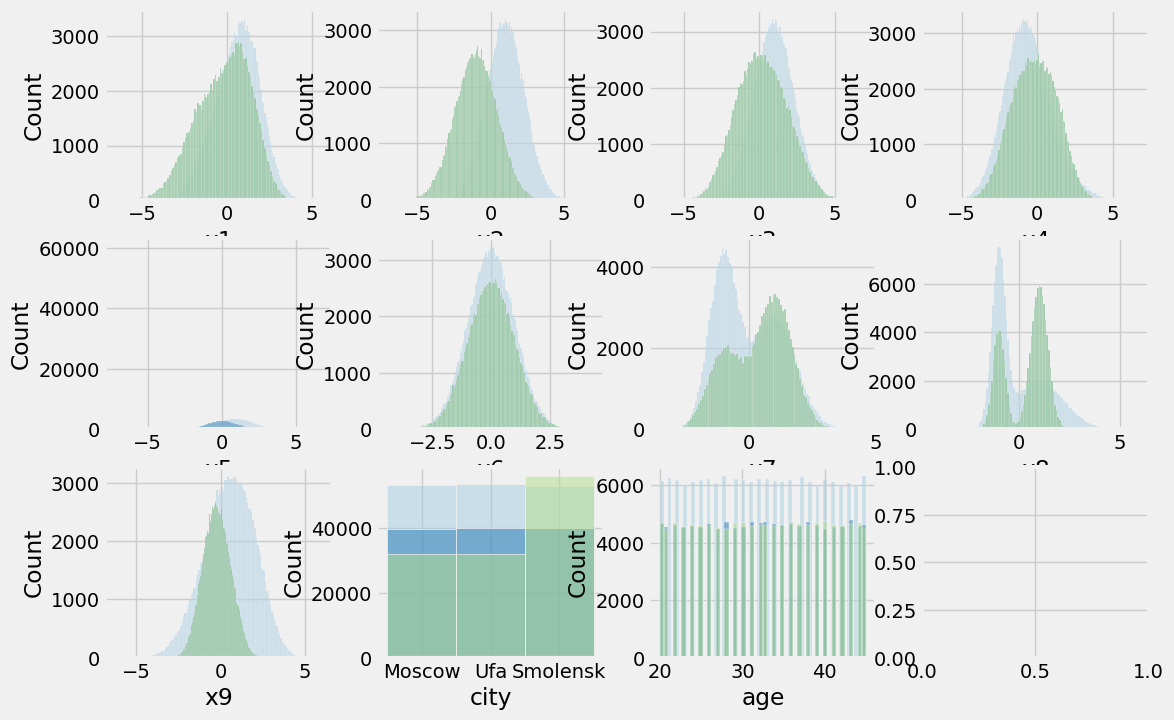

In [173]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axis = plt.subplots(3, 4, figsize=(12,8))
axis = axis.flatten()
for j in range(3):
    for i, value in enumerate(['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 'city', 'age']):
        sns.histplot(data=CampaingListMergeAggr[j], x=value, ax=axis[i], alpha=0.5)

Получаем, что многие признаки имеют нечто близкое к нормальному распределению. Есть дисбалансы в признаках x7 и x8 - возможно они укажут нам на зависимости от коммуникаций

In [174]:
CampaingListMergeAggr[2]['x5'].value_counts()[0]

np.int64(60000)

В x5 неприятный выброс для одной из кампаний. Предлагаю выкинуть столбцы x5 и x6, так как они почти не несут в себе информацию

In [175]:
for i in range(3):
    CampaingListMergeAggr[i] = CampaingListMergeAggr[i].drop(columns=['x5', 'x6'])

Итак, теперь построим таргет:
1. Если t_flag = 1, то таргет строится по правилу contract_date - delivery_date <= 2 недели
2. t_flag = 0 $\Rightarrow$ contract_date - 2024-11-01 <= 3 недели

In [176]:
ResultTables = []
for i in range(3):
    tmp1 = CampaingListMergeAggr[i][CampaingListMergeAggr[i]['t_flag'] == 1].copy()
    tmp0 = CampaingListMergeAggr[i][CampaingListMergeAggr[i]['t_flag'] == 0].copy()
    tmp1['target'] = ((pd.to_datetime(tmp1['contract_date']) - pd.to_datetime(tmp1['delivery_date'])) <= pd.Timedelta(days=14)).astype(int)
    tmp0['target'] = ((pd.to_datetime(tmp0['contract_date']) - pd.to_datetime('2024-11-01') <= pd.Timedelta(days=21))).astype(int)
    ResultTables.append(pd.concat([tmp1, tmp0], ignore_index=True))

In [177]:
ResultTables[0].head(2)

,user_id,t_flag,delivery_date,contract_date,x1,x2,x3,x4,x7,x8,x9,age,city,target
0,1162,1,2024-11-08,2024-11-13,-1.224545,1.688111,0.150933,3.230149,-1.229590,1.159411,-0.08572,39,Moscow,1
1,42991,1,2024-11-07,2025-01-01,-0.916137,1.368764,1.841319,-1.529691,1.178124,-0.884607,-1.72607,43,Moscow,0


<h2> 3. Построение моделей и оценка их качества (14 баллов)</h2>

Постройте Uplift модели по собранным кампаниям, проведите тюнинг гиперпараметров и оцените их качество (qini score). Для каждой модели также постройте qini-curve.

**Комментарий по заданиям и оцениванию:**

* Реализован только подход Solomodel без дополнительных библиотек и калибровок  - **1 балл**

* Реализован Solomodel или Twomodel через Sklift или CausalML - **2 балла**

* Учтена калибровка Metalearner'ах - **2 балла**

* Корректно реализован ClassTransformation - **2 балла**

* Реализован UpliftRandomForest - **4 балла**

* Использованы пайплайны в Sklift - **2 балла**

* Реализован тюнинг ( Gridsearch \ Optuna ) - **1 балл**

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import GradientBoostingClassifier
from causalml.metrics import qini_score, plot_qini
from causalml.inference.meta import BaseTClassifier
from sklearn.model_selection import train_test_split, GridSearchCV

В итоге: я не понял, как можно нормально совмещать causalml, пайплайны и гридсерч. Sklift просто не работает на новых версиях sklearn. Поэтому так

In [220]:
models = []
for i in range(3):
    numeric_col = ['x1', 'x2', 'x3', 'x4', 'x7', 'x8', 'x9', 'age']
    categorial_col = ['city']
    X = ResultTables[i][numeric_col + categorial_col]
    y = ResultTables[i]['target']
    t = ResultTables[i]['t_flag']

    X_train, X_test, y_train, y_test, t_train, t_test = train_test_split(
        X, y, t, test_size=0.3, random_state=42
    )

    preprocess = ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorial_col),
        ("num", "passthrough", numeric_col)
    ])

    X_train = preprocess.fit_transform(X_train)
    X_test = preprocess.transform(X_test)

    t_learner = BaseTClassifier(learner=GradientBoostingClassifier())
    t_learner.fit(X=X_train, treatment=t_train.values, y=y_train.values)

    uplift = t_learner.predict(X_test).ravel()
    models.append(t_learner)
    df = pd.DataFrame({
        'y_true': y_test.values,
        'treatment': t_test.values,
        'uplift': uplift
    })

    score = qini_score(df=df, outcome_col='y_true', treatment_col='treatment', uplift_col='uplift')
    print(score)

uplift    0.215059
dtype: float64
uplift    0.302118
dtype: float64
uplift    0.291111
dtype: float64


А кривая у меня просто не запускается, как бы я не пробовал.

<h2>4. Подготовка ответа в требуемом формате и подготовка выводов (6 баллов)</h2>

a) Сделайте скоринг нужных клиентов, подготовьте ответ в требуемом формате

б) Сделайте краткую аналитику того, какой канал взаимодействия наиболее предпочтителен

в) Сделайте выводы по проделанной работе

**Комментарий по заданиям и оцениванию:**

* Подготовлен только ответ - **1 балл**
* Подготовлен содержательный вывод по проделанной работе - **4 балла**
* Корректно принято решение об отправке/не отправке коммуникации клиентам в зависимости от значений Uplift - **1 балл**

In [240]:
Aggregates = pd.read_csv('content/ДЗ по Uplift обновленное/AGGS_FINAL.csv')

In [241]:
Aggregates = Aggregates[Aggregates['report_dt'] == '2025-01-31']
Aggregates.shape

(460000, 14)

In [242]:
Aggregates = Aggregates.drop(columns=['x5', 'x6', 'Unnamed: 0'])
AggrX = Aggregates[numeric_col + categorial_col]
AggrX = preprocess.transform(AggrX)

In [253]:
predicts = pd.DataFrame()
for i in range(3):
    predicts[i] = (models[i].predict(AggrX).ravel())

In [254]:
predicts['uplift_max'] = np.max(predicts, axis=1)
predicts['uplift_idx'] = np.argmax(predicts, axis=1)

In [256]:
predicts.head(2)

,0,1,2,uplift_max,uplift_idx
0,0.457988,0.014240,0.020966,0.457988,0
1,0.049985,0.017034,0.018913,0.049985,0


In [257]:
dict_channel = {0 :'push', 1:'banner', 2:'other'}

In [260]:
predicts['uplift_idx']=predicts['uplift_idx'].map(dict_channel)

In [261]:
predicts.head(2)

,0,1,2,uplift_max,uplift_idx
0,0.457988,0.014240,0.020966,0.457988,push
1,0.049985,0.017034,0.018913,0.049985,push


In [268]:
FINAL = Aggregates[['user_id', 'report_dt']]
FINAL = FINAL.reset_index(drop=True)
FINAL['uplift'] = predicts['uplift_max']
FINAL['channel'] = predicts['uplift_idx']
FINAL

,user_id,report_dt,uplift,channel
0,1066338,2025-01-31,0.457988,push
1,25872,2025-01-31,0.049985,push
2,4107442,2025-01-31,0.923119,push
3,2047420,2025-01-31,0.360160,banner
4,1120643,2025-01-31,0.032027,push
...,...,...,...,...
459995,4034876,2025-01-31,0.078923,push
459996,114148,2025-01-31,0.988121,push
459997,143255,2025-01-31,0.019862,push
459998,132172,2025-01-31,0.108603,other


### ваши выводы здесь

In [271]:
FINAL['uplift'].mean()

np.float64(0.5128498800165332)

In [269]:
FINAL['channel'].value_counts()

channel
push      324406
banner     87725
other      47869
Name: count, dtype: int64

Больше всего влияет в среднем push канал. Есть предположения, что sms будут тоже эффективны.

In [272]:
FINAL[FINAL['uplift'] > 0.4]['channel'].value_counts()

channel
push      205800
banner     30995
other      14600
Name: count, dtype: int64

Ощутимый эффект также наблюдается для канала push

In [273]:
FINAL[FINAL['uplift'] < 0].shape

(1704, 4)

Есть пользователи, которых трогать не стоит, но их меньшинство

Коммуникации крутые, используем

В итоге работа мне не понравилась - библиотеки не совместимы друг с другом (sklift с sklearn новых версий), casualml не работает с пайплайнами sklearn. Как тогда делать гридсерч - вообще непонятно.
По сути в конце я взял случайную модель из бустингов - подбора гиперпараметров не было, и непонятно, как нормально запустить перебор